# 1.5.10 Feature Matching + Homography to find Objects

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [2]:
MIN_MATCH_COUNT = 10
img1 = cv2.imread('momopop1.png',0) # queryImage
img2 = cv2.imread('momopop2.jpg',0) # trainImage

In [3]:
# Initiate SIFT detector
sift = cv2.SIFT_create()
# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

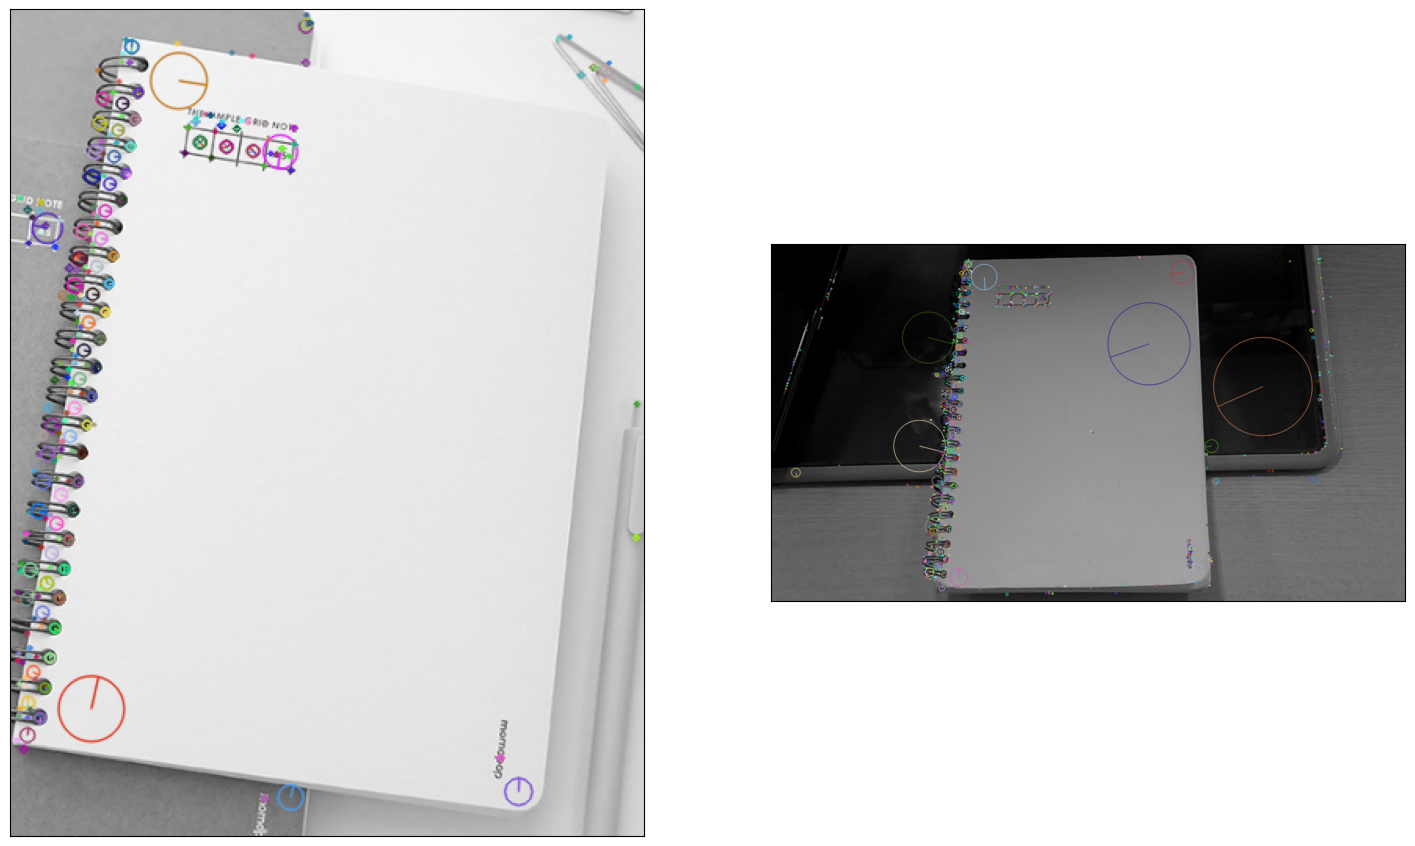

In [4]:
img1v = cv2.drawKeypoints(img1, kp1, img1, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS) #,flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
img2v = cv2.drawKeypoints(img2, kp2, img2, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.figure(figsize = (18,18))
plt.subplot(1,2,1), plt.imshow(img1v), plt.xticks([]), plt.yticks([])
plt.subplot(1,2,2), plt.imshow(img2v), plt.xticks([]), plt.yticks([])
plt.show()

In [5]:
FLANN_INDEX_KDTREE = 0
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1,des2,k=2)

In [6]:
# store all the good matches as per Lowe's ratio test.
good = []
for m,n in matches:
    if m.distance < 0.5*n.distance:
        good.append(m)

In [7]:
print(len(good))

10


In [8]:
if len(good)>MIN_MATCH_COUNT:
    src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,5.0)
    matchesMask = mask.ravel().tolist()
    h,w = img1.shape
    pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
    dst = cv2.perspectiveTransform(pts,M)
    img2 = cv2.polylines(img2,[np.int32(dst)],True,255,3, cv2.LINE_AA)
else:
    print("Not enough matches are found - %d/%d" % (len(good),MIN_MATCH_COUNT))
    matchesMask = None

Not enough matches are found - 10/10


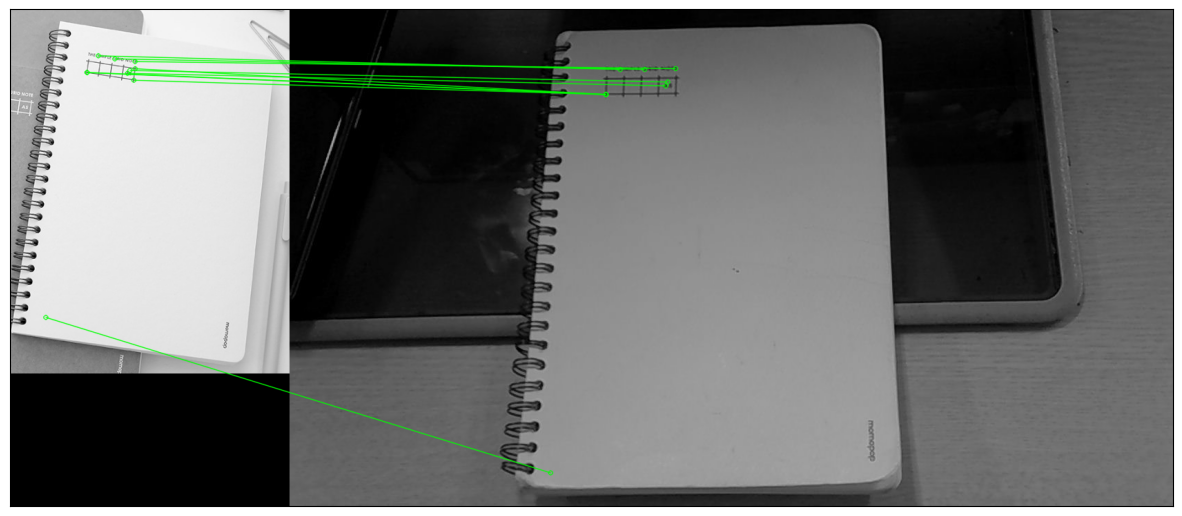

(<matplotlib.image.AxesImage at 0x2860b6b34c0>, ([], []), ([], []), None)

In [9]:
draw_params = dict(matchColor = (0,255,0), singlePointColor = None, matchesMask = matchesMask, flags = 2)
img3 = cv2.drawMatches(img1,kp1,img2,kp2,good,None,**draw_params)
plt.figure(figsize = (15,15))
plt.imshow(img3, 'gray'), plt.xticks([]), plt.yticks([]), plt.show()

In [ ]:
cap = cv2.VideoCapture(0)
while(cap.isOpened()):
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    kp2, des2 = sift.detectAndCompute(gray,None)
    img2v = cv2.drawKeypoints(frame, kp2, frame, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    if len(kp2) > 10 :
        matches = flann.knnMatch(des1,des2,k=2)
        good = []
        for m,n in matches:
            if m.distance < 0.75*n.distance:
                good.append(m)
    if len(good)>MIN_MATCH_COUNT: 
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC,5.0)
        matchesMask = mask.ravel().tolist()
        h,w = img1.shape
        pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
        dst = cv2.perspectiveTransform(pts,M)
        frame = cv2.polylines(frame,[np.int32(dst)],True,255,3, cv2.LINE_AA)
    else:
        print("Not enough matches are found - %d/%d" % (len(good),MIN_MATCH_COUNT))
        matchesMask = None

    draw_params = dict(matchColor = (0,255,0), singlePointColor = None, matchesMask = matchesMask, flags = 2)
    img3 = cv2.drawMatches(img1,kp1,frame,kp2,good,None,**draw_params)

    cv2.imshow('frame',img3)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

288
289
283
266
161
182
224
260
237
239
161
125
169
219
137
61
Not enough matches are found - 2/10
45
Not enough matches are found - 4/10
51
Not enough matches are found - 4/10
83
Not enough matches are found - 9/10
96
Not enough matches are found - 1/10
71
Not enough matches are found - 4/10
292
254
271
294
200
311
338
318
320
321
310
320
335
302
310
291
319
322
334
294
307
323
190
159
143
127
133
288
248
329
251
298
298
271
253
288
284
272
307
319
265
210
177
205
180
227
241
160


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\matmul.dispatch.cpp:550: error: (-215:Assertion failed) scn + 1 == m.cols in function 'cv::perspectiveTransform'


: 

In [ ]:
cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    kp2, des2 = sift.detectAndCompute(gray, None)

    img2v = cv2.drawKeypoints(frame, kp2, frame,
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

    # 🔥 핵심 방어 코드
    if des1 is None or des2 is None:
        cv2.imshow('frame', img2v)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        continue

    des1 = np.float32(des1)
    des2 = np.float32(des2)

    matches = flann.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.5 * n.distance:
            good.append(m)

    print(len(good))

    cv2.imshow('frame', img2v)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()